# 1. Reading Data

In [8]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.feature_selection import SelectKBest, chi2, VarianceThreshold



df = pd.read_csv("Work Productivity.csv")

df = df.drop(["Employee_ID", "Productivity_Score"], axis=1)


# 2. Preprocessing


Missing Values:
 Age                        0
Gender                     0
Country                    0
Job_Role                   0
Experience_Years           0
Company_Size               0
Work_Hours_Per_Day         0
Meetings_Per_Day           0
Internet_Speed_Mbps        0
Work_Environment           0
Sleep_Hours                0
Exercise_Hours_Per_Week    0
Screen_Time_Hours          0
Stress_Level               0
Burnout_Risk               0
dtype: int64

Duplicates: 0


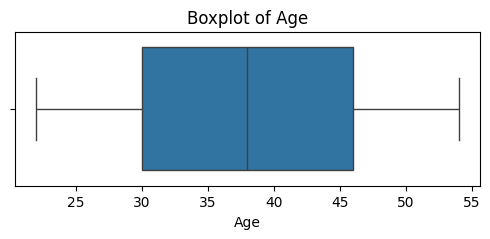

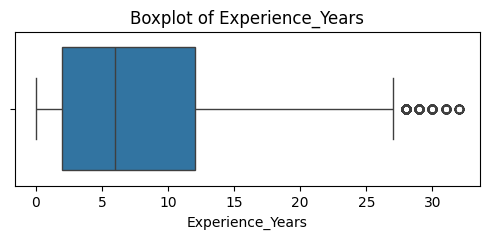

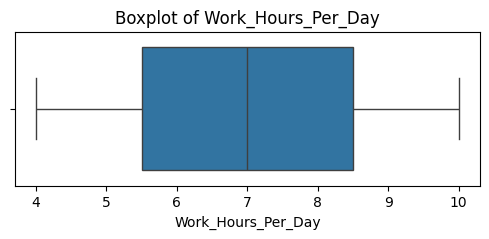

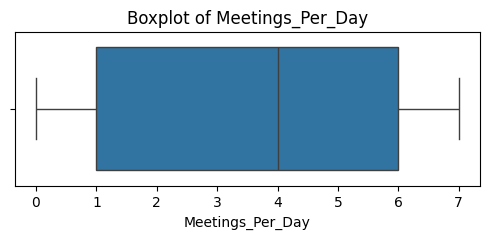

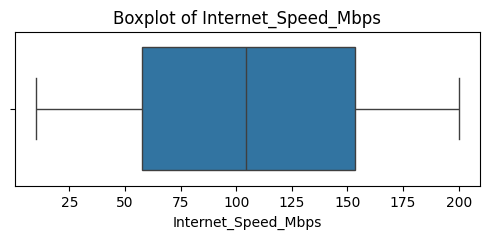

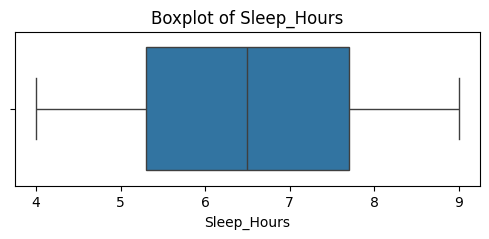

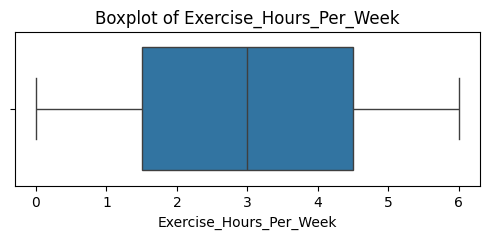

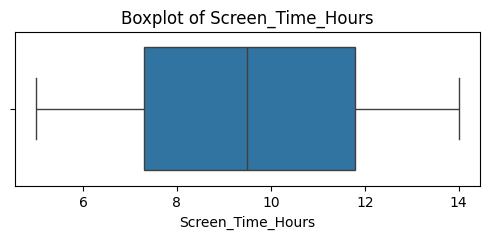

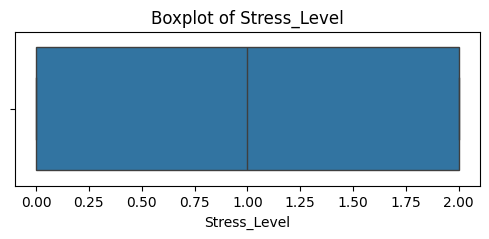


Shape before removing outliers: (30000, 15)

Shape after removing outliers: (29576, 15)

Final Missing Values:
 Age                        0
Gender                     0
Country                    0
Job_Role                   0
Experience_Years           0
Company_Size               0
Work_Hours_Per_Day         0
Meetings_Per_Day           0
Internet_Speed_Mbps        0
Work_Environment           0
Sleep_Hours                0
Exercise_Hours_Per_Week    0
Screen_Time_Hours          0
Stress_Level               0
Burnout_Risk               0
dtype: int64

Final Shape: (29576, 15)


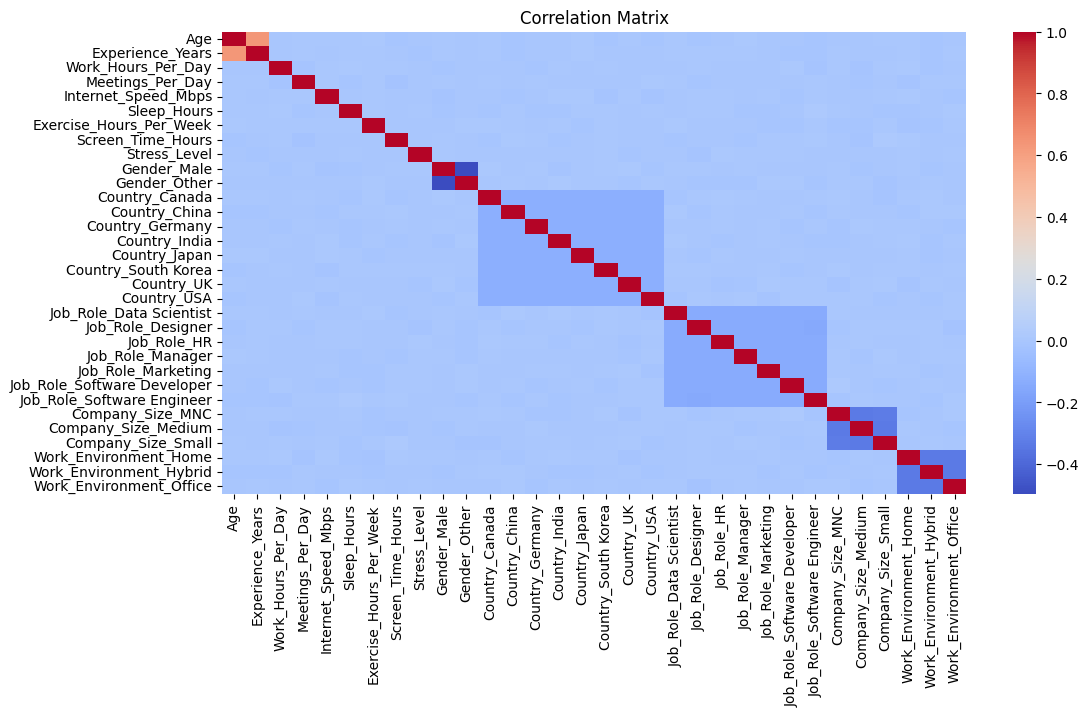


Top Features (Chi-Square):
Index(['Work_Hours_Per_Day', 'Meetings_Per_Day', 'Internet_Speed_Mbps',
       'Sleep_Hours', 'Exercise_Hours_Per_Week', 'Screen_Time_Hours',
       'Country_South Korea', 'Country_USA', 'Job_Role_HR',
       'Company_Size_MNC'],
      dtype='str')

Features after Variance Threshold:
Index(['Age', 'Experience_Years', 'Work_Hours_Per_Day', 'Meetings_Per_Day',
       'Internet_Speed_Mbps', 'Sleep_Hours', 'Exercise_Hours_Per_Week',
       'Screen_Time_Hours', 'Stress_Level', 'Gender_Male', 'Gender_Other',
       'Country_Canada', 'Country_China', 'Country_Germany', 'Country_India',
       'Country_Japan', 'Country_South Korea', 'Country_UK', 'Country_USA',
       'Job_Role_Data Scientist', 'Job_Role_Designer', 'Job_Role_HR',
       'Job_Role_Manager', 'Job_Role_Marketing', 'Job_Role_Software Developer',
       'Job_Role_Software Engineer', 'Company_Size_MNC', 'Company_Size_Medium',
       'Company_Size_Small', 'Work_Environment_Home',
       'Work_Environment_H

In [9]:


# ------------------------------
# 1. Missing Values
# ------------------------------
print("\nMissing Values:\n", df.isnull().sum())

df = df.dropna()

# ------------------------------
# 2. Duplicates
# ------------------------------
print("\nDuplicates:", df.duplicated().sum())

df = df.drop_duplicates()

# ------------------------------
# 3. Encoding
# ------------------------------
df["Stress_Level"] = df["Stress_Level"].map({
    "Low": 0,
    "Medium": 1,
    "High": 2
})

df["Burnout_Risk"] = df["Burnout_Risk"].map({
    "No": 0,
    "Yes": 1
})

df = df.dropna()

# ------------------------------
# 🔴 مهم: عرف numeric_cols هنا
# ------------------------------
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
numeric_cols = [col for col in numeric_cols if col != "Burnout_Risk"]

# ------------------------------
# 4. Boxplot (Visualization)
# ------------------------------
for col in numeric_cols:
    plt.figure(figsize=(6,2))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

print("\nShape before removing outliers:", df.shape)

# ------------------------------
# 5. Outliers Removal (IQR)
# ------------------------------
def remove_outliers(df, cols):
    for col in cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        df = df[(df[col] >= lower) & (df[col] <= upper)]

    return df

df = remove_outliers(df, numeric_cols)

print("\nShape after removing outliers:", df.shape)

# ------------------------------
# 6. Final Check
# ------------------------------
print("\nFinal Missing Values:\n", df.isnull().sum())
print("\nFinal Shape:", df.shape)


# ------------------------------
# 7. Feature Selection / Dimension Reduction
# ------------------------------

# فصل X و y
X = df.drop("Burnout_Risk", axis=1)
y = df["Burnout_Risk"]

# ------------------------------
# 🔴 تحويل الكاتيجوري لأرقام (مهم جدًا)
# ------------------------------
X_encoded = pd.get_dummies(X, drop_first=True)

# ------------------------------
# 7.1 Correlation Matrix
# ------------------------------
plt.figure(figsize=(12,6))
sns.heatmap(X_encoded.corr(), cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

# ------------------------------
# 7.2 Chi-Square
# ------------------------------

# لازم كل القيم تبقى موجبة
X_positive = X_encoded.copy()
X_positive = X_positive.apply(lambda x: x - x.min() if x.min() < 0 else x)

chi_selector = SelectKBest(score_func=chi2, k=10)
X_chi = chi_selector.fit_transform(X_positive, y)

selected_features_chi = X_encoded.columns[chi_selector.get_support()]
print("\nTop Features (Chi-Square):")
print(selected_features_chi)

# ------------------------------
# 7.3 Variance Threshold
# ------------------------------

selector_var = VarianceThreshold(threshold=0.01)
X_var = selector_var.fit_transform(X_encoded)

selected_features_var = X_encoded.columns[selector_var.get_support()]
print("\nFeatures after Variance Threshold:")
print(selected_features_var)

# Logistic Regression - Abdelrahman Emad


✅ Accuracy: 94.86%

=== REQUIRED INPUT STRUCTURE ===

Columns needed:
['Age', 'Gender', 'Country', 'Job_Role', 'Experience_Years', 'Company_Size', 'Work_Hours_Per_Day', 'Meetings_Per_Day', 'Internet_Speed_Mbps', 'Work_Environment', 'Sleep_Hours', 'Exercise_Hours_Per_Week', 'Screen_Time_Hours', 'Stress_Level']

Possible values for Gender:
<StringArray>
['Other', 'Female', 'Male']
Length: 3, dtype: str

Possible values for Country:
<StringArray>
['South Korea',       'India',   'Australia',         'USA',          'UK',
      'Canada',     'Germany',       'China',       'Japan']
Length: 9, dtype: str

Possible values for Job_Role:
<StringArray>
['Software Developer',                 'HR',       'Data Analyst',
           'Designer',  'Software Engineer',          'Marketing',
            'Manager',     'Data Scientist']
Length: 8, dtype: str

Possible values for Company_Size:
<StringArray>
['Large', 'Small', 'Medium', 'MNC']
Length: 4, dtype: str

Possible values for Work_Environment:


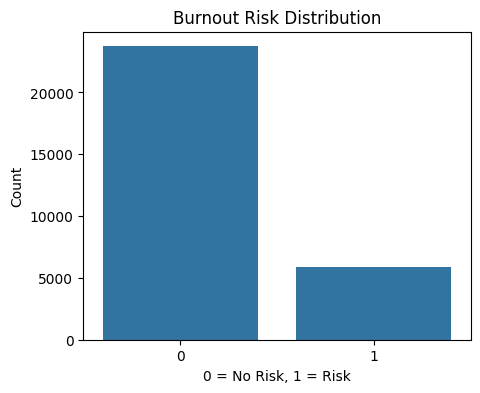

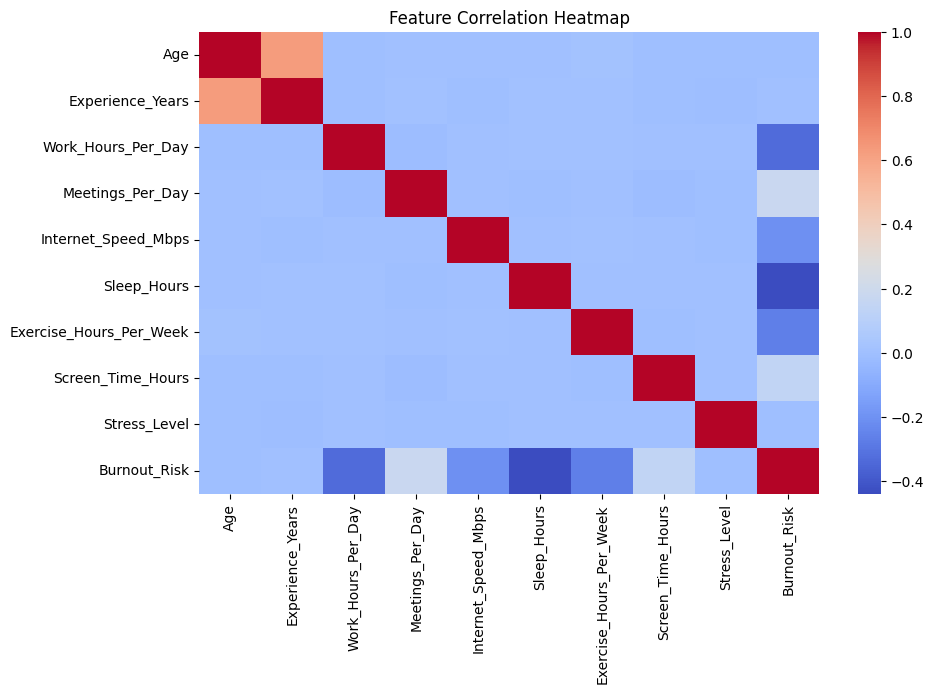

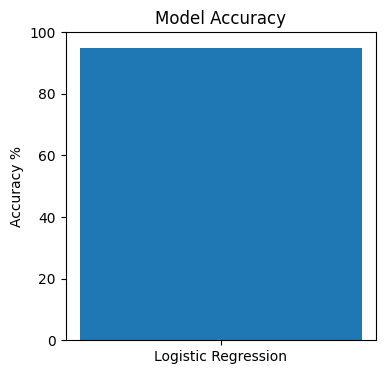

In [10]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# ==============================
# 1. Split Data
# ==============================
X = df.drop("Burnout_Risk", axis=1)
y = df["Burnout_Risk"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# ==============================
# 2. Columns
# ==============================
categorical_cols = ["Gender", "Country", "Job_Role", "Company_Size", "Work_Environment"]
numerical_cols = [col for col in X.columns if col not in categorical_cols]

# ==============================
# 3. Preprocessor + Model
# ==============================
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_cols),
    ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_cols)
])

model = Pipeline([
    ("preprocessing", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

# ==============================
# 4. Train
# ==============================
model.fit(X_train, y_train)

# ==============================
# 5. Evaluate
# ==============================
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred) * 100
print(f"\n✅ Accuracy: {accuracy:.2f}%")

# ==============================
# 6. Required Input Info
# ==============================
print("\n=== REQUIRED INPUT STRUCTURE ===")

print("\nColumns needed:")
print(X.columns.tolist())

for col in categorical_cols:
    print(f"\nPossible values for {col}:")
    print(df[col].unique())

print("\nStress_Level values:")
print(["Low", "Medium", "High"])

# ==============================
# 7. User Input
# ==============================
user_data = {
    "Age": 30,
    "Gender": "Male",
    "Country": "USA",
    "Job_Role": "Software Engineer",
    "Experience_Years": 5,
    "Company_Size": "Medium",
    "Work_Hours_Per_Day": 8,
    "Meetings_Per_Day": 3,
    "Internet_Speed_Mbps": 50,
    "Work_Environment": "Hybrid",
    "Sleep_Hours": 6,
    "Exercise_Hours_Per_Week": 2,
    "Screen_Time_Hours": 7,
    "Stress_Level": "High"
}

# تحويل لـ DataFrame
user_df = pd.DataFrame([user_data])

# Encoding
user_df["Stress_Level"] = user_df["Stress_Level"].map({
    "Low": 0,
    "Medium": 1,
    "High": 2
})

# نفس ترتيب الأعمدة
user_df = user_df[X.columns]

# Check NaN
print("\nCheck NaN:\n", user_df.isnull().sum())

# ==============================
# 8. Prediction
# ==============================
prediction = model.predict(user_df)[0]

if prediction == 1:
    print("\n⚠️ Burnout Risk: YES")
else:
    print("\n✅ Burnout Risk: NO")

plt.figure(figsize=(5,4))
sns.countplot(x=y)
plt.title("Burnout Risk Distribution")
plt.xlabel("0 = No Risk, 1 = Risk")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm", annot=False)
plt.title("Feature Correlation Heatmap")
plt.show()

plt.figure(figsize=(4,4))
plt.bar(["Logistic Regression"], [accuracy])
plt.ylim(0, 100)
plt.title("Model Accuracy")
plt.ylabel("Accuracy %")
plt.show()

# decision tree - Gamila Refaat


=== Decision Tree Results ===
Accuracy: 91.16 %
Prediction: YES


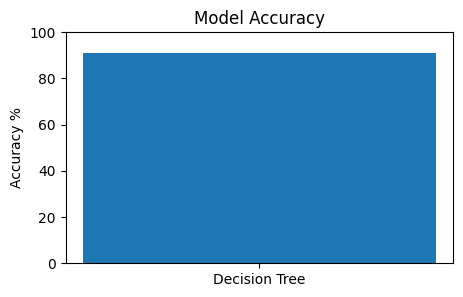

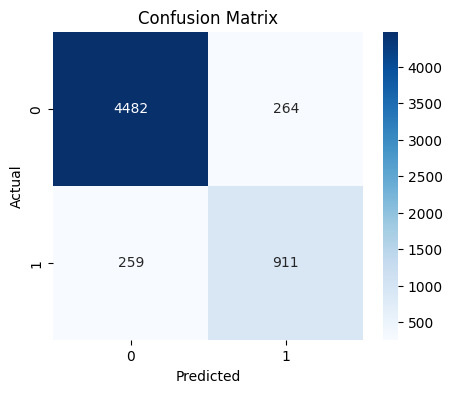

In [11]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.metrics import accuracy_score, confusion_matrix

# ==============================
# Preprocessing Pipeline
# ==============================
preprocessor = ColumnTransformer([
    ("num", MinMaxScaler(), numerical_cols),
    ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_cols)
])

# ==============================
# Decision Tree Model
# ==============================
model = Pipeline([
    ("preprocessing", preprocessor),

    ("feature_selection", SelectKBest(score_func=chi2, k=10)),

    ("classifier", DecisionTreeClassifier(
        max_depth=10,
        random_state=42
    ))
])

# ==============================
# Train
# ==============================
model.fit(X_train, y_train)

# ==============================
# Predict
# ==============================
y_pred = model.predict(X_test)

# ==============================
# Evaluation
# ==============================
print("\n=== Decision Tree Results ===")
print("Accuracy:", round(accuracy_score(y_test, y_pred) * 100, 2), "%")

user_data = {
    "Age":36,
    "Gender":"Male",
    "Country":"USA",
    "Job_Role":"Software Engineer",
    "Experience_Years":12,
    "Company_Size":"Medium",
    "Work_Hours_Per_Day":4.4,
    "Meetings_Per_Day":6,
    "Internet_Speed_Mbps":90.4,
    "Work_Environment":"Home",
    "Sleep_Hours":5,
    "Exercise_Hours_Per_Week":5,
    "Screen_Time_Hours":7,
    "Stress_Level":2,
}

user_df = pd.DataFrame([user_data])

pred = model.predict(user_df)

print("Prediction:", "YES" if pred[0]==1 else "NO")

# ==============================
# 🔥 1. Accuracy Bar Chart
# ==============================
acc = accuracy_score(y_test, y_pred) * 100
plt.figure(figsize=(5,3))
plt.bar(["Decision Tree"], [acc])
plt.ylim(0, 100)
plt.title("Model Accuracy")
plt.ylabel("Accuracy %")
plt.show()

# ==============================
# 🔥 2. Confusion Matrix Chart
# ==============================
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()



# random forest - Amr Khalid


=== Random Forest Results ===
Accuracy: 94.03 %

Classification Report:

              precision    recall  f1-score   support

           0       0.97      0.96      0.96      4746
           1       0.83      0.87      0.85      1170

    accuracy                           0.94      5916
   macro avg       0.90      0.91      0.91      5916
weighted avg       0.94      0.94      0.94      5916


🔎 Result:
✅ Burnout Risk: NO


c:\Users\ADMIN\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


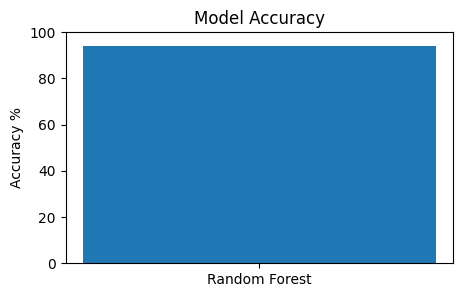

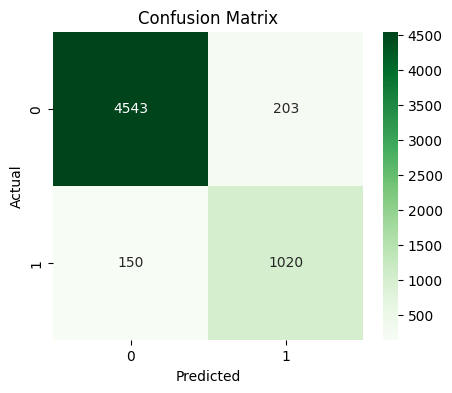

In [19]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectKBest, f_classif
from imblearn.over_sampling import SMOTE
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder

# ==============================
#  Encode ALL categorical columns
# ==============================
encoders = {}

for col in X.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    encoders[col] = le

# ==============================
#  Feature Selection (NOW SAFE)
# ==============================
selector = SelectKBest(score_func=f_classif, k=10)
X_selected = selector.fit_transform(X, y)

# ==============================
# Train / Test Split
# ==============================
X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# ==============================
# SMOTE (Handling imbalance)
# ==============================
smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

# ==============================
# Random Forest Model
# ==============================
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

# ==============================
# Evaluation
# ==============================
y_pred = model.predict(X_test)

print("\n=== Random Forest Results ===")
print("Accuracy:", round(accuracy_score(y_test, y_pred) * 100, 2), "%")
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))



# =========================
# 🔹 User Input
# =========================

input_data = {
    "Age": 30,
    "Gender": "Male",
    "Country": "USA",
    "Job_Role": "Software Engineer",
    "Experience_Years": 5,
    "Company_Size": "Medium",
    "Work_Hours_Per_Day": 9,
    "Meetings_Per_Day": 3,
    "Internet_Speed_Mbps": 50,
    "Work_Environment": "Hybrid",
    "Sleep_Hours": 6,
    "Exercise_Hours_Per_Week": 2,
    "Screen_Time_Hours": 7,
    "Stress_Level": "High"
}

df_input = pd.DataFrame([input_data])

df_input = df_input.reindex(columns=X.columns, fill_value=0)

df_input = pd.DataFrame([input_data])

# Encode categorical using saved encoders
for col in encoders:
    if col in df_input.columns:
        le = encoders[col]
        val = df_input.at[0, col]
        if val in le.classes_:
            df_input.at[0, col] = le.transform([val])[0]
        else:
            df_input.at[0, col] = -1

        

# Keep only selected features
selector = SelectKBest(score_func=f_classif, k=10)
X_selected = selector.fit_transform(X, y)

# ✅ ADD THIS LINE (THIS FIXES YOUR ERROR)
selected_features = X.columns[selector.get_support()]

df_input = df_input.reindex(columns=selected_features, fill_value=0)

# safe numeric conversion
df_input = df_input.apply(pd.to_numeric, errors='coerce').fillna(0)

# prediction
prediction = model.predict(df_input)[0]
print("\n🔎 Result:")
if prediction == 1:
    print("⚠️ Burnout Risk: YES")
else:
    print("✅ Burnout Risk: NO")

 # ==============================
# 🔥 1. Accuracy Chart
# ==============================
acc = accuracy_score(y_test, y_pred) * 100
plt.figure(figsize=(5,3))
plt.bar(["Random Forest"], [acc])
plt.ylim(0, 100)
plt.title("Model Accuracy")
plt.ylabel("Accuracy %")
plt.show()

# ==============================
# 🔥 2. Confusion Matrix
# ==============================
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


# support vector machine - Dalia Mohamed

Accuracy: 0.9056795131845842


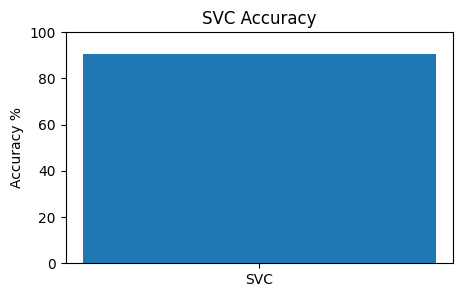

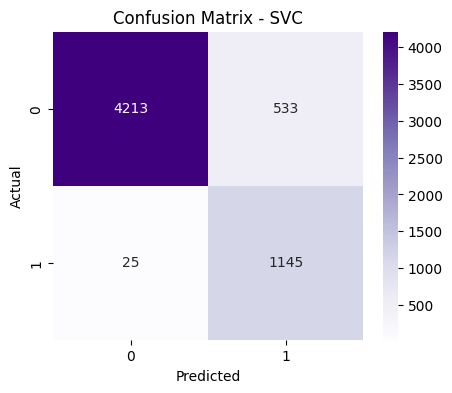

In [20]:
import pandas as pd
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

model = SVC(kernel="rbf")

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

# =========================
# User Input
# =========================
user_data = {
    "Age": 36,
    "Gender": "Male",
    "Country": "USA",
    "Job_Role": "Software Engineer",
    "Experience_Years": 12,
    "Company_Size": "Medium",
    "Work_Hours_Per_Day": 4.4,
    "Meetings_Per_Day": 6,
    "Internet_Speed_Mbps": 90.4,
    "Work_Environment": "Home",
    "Sleep_Hours": 5,
    "Exercise_Hours_Per_Week": 5,
    "Screen_Time_Hours": 7,
    "Stress_Level": 2,
}

# تحويل لـ DataFrame
user_df = pd.DataFrame([user_data])

# نفس encoding
user_df = pd.get_dummies(user_df)

# نفس الأعمدة
user_df = user_df.reindex(columns=X.columns, fill_value=0)

# 🔴 مهم جدًا: نفس Feature Selection
user_df_selected = selector.transform(user_df)

# Prediction
pred = model.predict(user_df_selected)

# ==============================
# 1. Accuracy Chart
# ==============================
acc = accuracy_score(y_test, y_pred) * 100
plt.figure(figsize=(5,3))
plt.bar(["SVC"], [acc])
plt.ylim(0, 100)
plt.title("SVC Accuracy")
plt.ylabel("Accuracy %")
plt.show()

# ==============================
# 2. Confusion Matrix Chart
# ==============================
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Purples")
plt.title("Confusion Matrix - SVC")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# PCA with logistic regression

In [21]:
# ==============================
# PCA + Model + Accuracy
# ==============================

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# ------------------------------
# 1. Scaling (مهم قبل PCA)
# ------------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_encoded)

# ------------------------------
# 2. PCA
# ------------------------------
pca = PCA(n_components=5)  # جرب 5 أو 8 أو 10
X_pca = pca.fit_transform(X_scaled)

print("Shape before PCA:", X_encoded.shape)
print("Shape after PCA:", X_pca.shape)

print("\nExplained Variance Ratio:")
print(pca.explained_variance_ratio_)

print("\nTotal Variance Retained:",
      sum(pca.explained_variance_ratio_))

# ------------------------------
# 3. Train/Test Split
# ------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X_pca, y, test_size=0.2, random_state=42
)

# ------------------------------
# 4. Model
# ------------------------------
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# ------------------------------
# 5. Prediction
# ------------------------------
y_pred = model.predict(X_test)

# ------------------------------
# 6. Evaluation
# ------------------------------
acc = accuracy_score(y_test, y_pred)

print("\n=== PCA Model Results ===")
print("Accuracy:", round(acc * 100, 2), "%")

Shape before PCA: (29576, 32)
Shape after PCA: (29576, 5)

Explained Variance Ratio:
[0.05108702 0.04685551 0.04231239 0.04188978 0.04164181]

Total Variance Retained: 0.22378651332837035

=== PCA Model Results ===
Accuracy: 79.99 %
